<a href="https://colab.research.google.com/github/Divanshu-Bansal/Machine-Learning-Algorithms/blob/master/Decision_Tree_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.datasets import load_iris

X,y = load_iris(return_X_y=True)

In [34]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [35]:
X_test.shape

(30, 4)

In [36]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(X_train,y_train)

DecisionTreeClassifier()

In [37]:
y_pred = dtc.predict(X_test)

In [38]:
from sklearn.metrics import classification_report,confusion_matrix

print("Classification Report:")
print(classification_report(y_test,y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


[Text(0.3076923076923077, 0.9285714285714286, 'x[3] <= 0.8\ngini = 0.667\nsamples = 120\nvalue = [40, 41, 39]'),
 Text(0.23076923076923078, 0.7857142857142857, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.2692307692307693, 0.8571428571428572, 'True  '),
 Text(0.38461538461538464, 0.7857142857142857, 'x[2] <= 4.75\ngini = 0.5\nsamples = 80\nvalue = [0, 41, 39]'),
 Text(0.34615384615384615, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'x[3] <= 1.65\ngini = 0.053\nsamples = 37\nvalue = [0, 36, 1]'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6153846153846154, 0.6428571428571429, 'x[3] <= 1.75\ngini = 0.206\nsamples = 43\nvalue = [0, 5, 38]'),
 Text(0.38461538461538464, 0.5, 'x[2] <= 4.95\ngini = 0.5\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.3076923076923077, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 

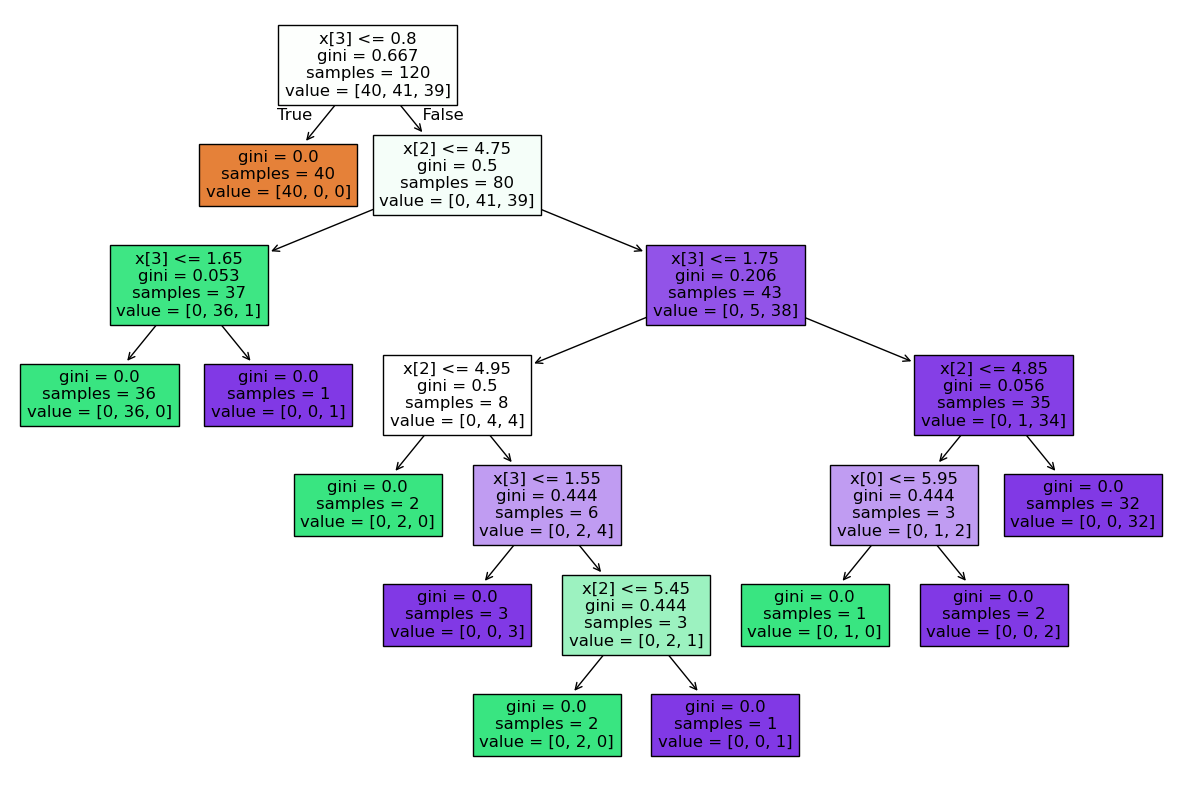

In [39]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dtc,filled=True)

## Decision Tree Classifier - Prepruning (Hyperparameter Tuning)

In [40]:
from sklearn.model_selection import GridSearchCV

In [41]:
params = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [1,2,3,4,5],
    'min_samples_split': [2,3,4]
}

In [46]:
grid = GridSearchCV(estimator=DecisionTreeClassifier(),param_grid=params,cv=5,verbose = 3)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV 1/5] END criterion=gini, max_depth=1, min_samples_split=2, splitter=best;, score=0.708 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, min_samples_split=2, splitter=best;, score=0.667 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, min_samples_split=2, splitter=best;, score=0.667 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=1, min_samples_split=2, splitter=best;, score=0.667 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=1, min_samples_split=2, splitter=best;, score=0.667 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=1, min_samples_split=2, splitter=random;, score=0.625 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, min_samples_split=2, splitter=random;, score=0.667 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, min_samples_split=2, splitter=random;, score=0.667 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=1, min_sample

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'min_samples_split': [2, 3, 4],
                         'splitter': ['best', 'random']},
             verbose=3)

In [47]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 4,
 'min_samples_split': 4,
 'splitter': 'random'}

In [48]:
y_pred_grid = grid.predict(X_test)

In [49]:
print("Classification Report:")
print(classification_report(y_test,y_pred_grid))
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_grid))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      1.00      0.90         9
           2       1.00      0.82      0.90        11

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.93        30
weighted avg       0.95      0.93      0.93        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  2  9]]
